In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import polars as pl

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

test_data_pl =  pl.read_csv(r"../data/test.csv",encoding="shift_jis")

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

In [4]:
import importlib
import ml_pipeline

importlib.reload(ml_pipeline)

from ml_pipeline import FeatureEngineer



fe = FeatureEngineer()

fe.fit(train_data_pl)
df_fe = fe.transform(train_data_pl)

In [5]:
df_fe.head(2)

sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,9970.62516,9966.76805,9962.91094,9959.05383,9955.19672,9951.33962,9947.48251,9943.6254,9939.76829,9935.91118,9932.05407,9928.19697,9924.33986,9920.48275,9916.62564,9912.76853,9908.91142,9905.05432,9901.19721,9897.3401,9893.48299,9889.62588,9885.76877,9881.91166,9878.05456,9874.19745,9870.34034,…,4100.10621,4096.2491,4092.39199,4088.53488,4084.67777,4080.82066,4076.96356,4073.10645,4069.24934,4065.39223,4061.53512,4057.67801,4053.82091,4049.9638,4046.10669,4042.24958,4038.39247,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1,"""イチョウ""",216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.4147,0.41452,0.41427,0.41392,0.41364,0.41354,0.41355,0.41352,0.41337,0.41312,0.41284,0.4127,0.41265,0.41257,0.41242,0.4123,0.41226,0.41218,0.41193,0.41159,0.41129,0.41111,0.41102,0.41096,0.41098,0.41109,0.41116,0.41104,…,1.22043,1.22559,1.22777,1.22751,1.22862,1.23165,1.23629,1.24109,1.24147,1.23927,1.24074,1.24282,1.24082,1.23906,1.24128,1.24471,1.24783,1.25104,1.24925,1.24145,1.2362,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219,173.660511,-9.390435,-3.582042,1.59253,1.34703,-3.169054,-1.658036,-2.170421,-0.090336,0.655449
2,1,"""イチョウ""",210.752688,0.42049,0.4204,0.42049,0.42053,0.42038,0.4201,0.41988,0.41966,0.41942,0.41932,0.41934,0.41934,0.41929,0.41914,0.41887,0.41858,0.41838,0.41829,0.41825,0.4182,0.41809,0.41794,0.4177,0.41753,0.41749,0.41739,0.41728,0.41727,0.41723,0.4171,0.41689,0.41664,0.41651,…,1.18393,1.18721,1.18827,1.18743,1.18784,1.19132,1.19635,1.19973,1.20052,1.20112,1.20575,1.21403,1.21904,1.21819,1.21739,1.22028,1.22197,1.21929,1.21611,1.21565,1.21745,1.2168,1.21205,1.21074,1.21508,1.21901,1.21846,172.181148,-12.046128,-4.557876,1.335985,0.885847,-2.530942,-1.515679,-1.623807,0.505572,0.540912


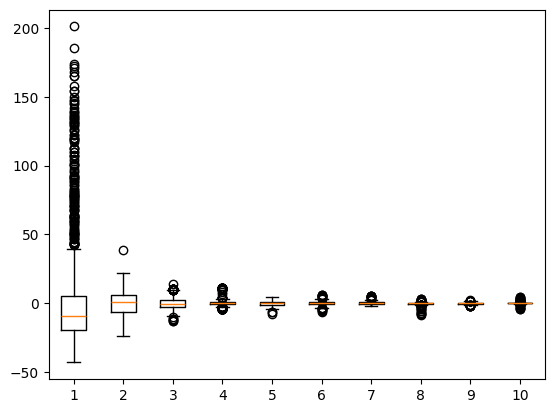

In [8]:
plt.boxplot(df_fe[["pca_0","pca_1","pca_2","pca_3","pca_4","pca_5","pca_6","pca_7","pca_8","pca_9"]])
plt.show()

In [ ]:
df_fe[["pca_0","pca_1","pca_2","pca_3","pca_4","pca_5","pca_6","pca_7","pca_8","pca_9"]].describe()

### 多重共線性の確認(ここから)

In [9]:
target_cols = ["含水率", "含水率_log"]

num_cols = [
    c for c in train_data_pl.columns
    if train_data_pl[c].dtype in (pl.Float64, pl.Int64)
    and c not in target_cols
]

In [10]:
df_sample = df_fe.sample(n=100, seed=42)

In [13]:
X = df_sample.select(num_cols).to_numpy()
corr = np.corrcoef(X, rowvar=False)

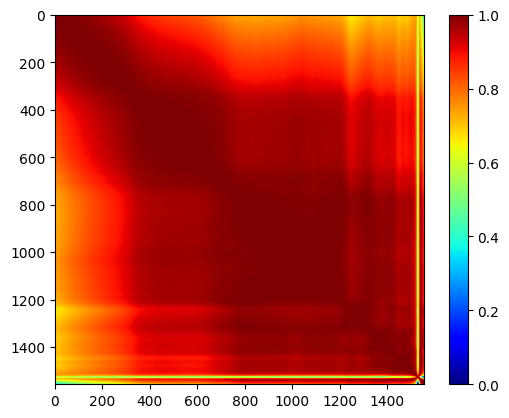

In [15]:

# ヒートマップ表示
plt.figure()
plt.imshow(corr,interpolation='nearest',vmin=0,vmax=1,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
draw_heatmap(corr)

In [ ]:
### 多重共線性の確認(ここまで)

In [38]:
# ① autoreload（まだなら）
%load_ext autoreload
%autoreload 2

# ② モジュール再読込
import importlib
import ml_pipeline
importlib.reload(ml_pipeline)

# ③ 再import
from ml_pipeline import MoisturePipeline

# ④ Pipeline作り直し（重要）
pipe = MoisturePipeline(species="gingo")

# ⑤ 学習
rmse = pipe.fit(train_data_pl)
print("RMSE:", rmse)

# ⑥ 予測
pred = pipe.predict(test_data_pl)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 399075
[LightGBM] [Info] Number of data points in the train set: 1057, number of used features: 1565
[LightGBM] [Info] Start training from score 3.463336


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
RMSE: 10.590954814625146
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [45]:
pred

array([172.05835196, 154.96835424, 168.06902624, 158.91077434,
       155.87539144, 151.31731627, 139.70487044, 140.93602613,
       141.58758928, 136.75739637, 136.36795309, 136.81778198,
       130.54529657, 127.31198445, 124.93683603, 119.20882075,
       119.31617661, 116.17373958, 116.17373958, 115.57064736,
       113.1267608 , 101.33168076, 103.09610192,  91.45048683,
        88.45982199,  84.34361892,  88.21338301,  84.54120847,
        79.61497964,  74.44895349,  61.81728184,  50.89938882,
        44.78968616,  35.1683292 ,  33.92797795,  37.79233098,
        37.12463612,  38.28954324,  38.7861176 ,  36.2380037 ,
        36.16382716,  36.29644774,  36.50777684,  36.30635786,
        36.14397661,  35.81802812,  35.800628  ,  35.03832334,
        34.56172366,  33.53084678,  33.34753585,  33.38302329,
        31.36109628,  31.17148004,  30.18107632,  29.92411622,
        30.27024583,  30.03002564,  30.00176186,  30.00176186,
        29.72768842,  29.70307114,  29.72768842,  29.07

In [47]:
type(pred)

numpy.ndarray

In [55]:
import numpy as np
import pandas as pd

In [65]:
submission = pd.DataFrame({
    "id": test_data_pl["sample number"],
    "含水率": pred
})

submission.head()

,id,含水率
0,95,172.058352
1,96,154.968354
2,97,168.069026
3,98,158.910774
4,99,155.875391


In [66]:
submission.to_csv(r"../data/submission.csv",index=False,header = False)

In [67]:
!head ../data/submission.csv

95,172.05835196019058
96,154.96835423939584
97,168.06902624475416
98,158.9107743370268
99,155.87539144148573
100,151.31731627356464
101,139.70487044231115
102,140.9360261298737
103,141.58758928450612
104,136.75739637428367


In [68]:
!head ../data/sample_submit.csv

95,50
96,50
97,50
98,50
99,50
100,50
101,50
102,50
103,50
104,50


In [64]:
test_data_pl["sample number"]

sample number
i64
95
96
97
98
99
…
1817
1818
1819
